## Steps

In [48]:
# 1. Data cleaning
# 2. EDA
# 3. Text Preprocessing
# 4. Model building
# 5. Evaluation
# 6. Improvement
# 7. Website
# 8. Deploy

## Importing and Data Load

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [50]:
# Option A: Standard Latin encoding
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [51]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,spam,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [52]:
df.shape

(6517, 5)

In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6517 entries, 0 to 6516
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          6517 non-null   str  
 1   v2          6358 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 254.7 KB


## Data Cleaning

In [54]:
df.isnull().sum()

v1               0
v2             159
Unnamed: 2    6467
Unnamed: 3    6505
Unnamed: 4    6511
dtype: int64

In [55]:
# We will erop last 3 clomuns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [56]:
# Now we will rename our columns
df.rename(columns={
    'v1':'Type',
    'v2':'Text'
},inplace=True)

In [57]:
df.head()

,Type,Text
0,spam,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [58]:
# Now we will encode the value of type
from sklearn.preprocessing import LabelEncoder
encoder= LabelEncoder()

df['Type'] = encoder.fit_transform(df['Type'])

In [59]:
# Looking for missing values
df.isnull().sum().sum()

np.int64(159)

In [60]:
# Looking for dupliate values
df.duplicated().sum()

np.int64(829)

In [61]:
# Removing duplicates
df= df.drop_duplicates(keep='first')

## EDA

In [62]:
df.head()

,Type,Text
0,1,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [63]:
df['Type'].value_counts()

Type
0    4531
1    1157
Name: count, dtype: int64

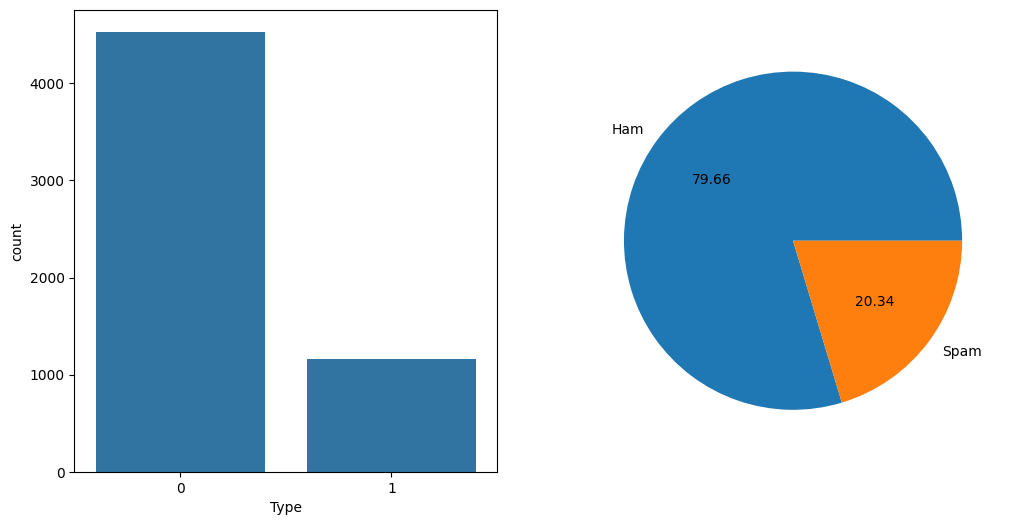

In [64]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.countplot(x='Type',data=df)
plt.subplot(1,2,2)
df['Type'].value_counts().plot(kind='pie',autopct='%0.2f',labels=['Ham','Spam'])
plt.show()

#### Seeing this we can say that out data is little imbalenced.....

In [65]:
# Now we have to import a library named nltk to find number of ch,words,sentences in the data
# First of all we have to install this
!pip install nltk

In [66]:
import nltk
nltk.download('punkt') # downloading the package for tokenization
nltk.download('punkt_tab')


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [67]:
df = df.dropna(subset=["Text"])
df['num_characters'] = df["Text"].apply(len)

In [68]:
# No of words
df['num_words'] = df['Text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [69]:
df['num_sentences']= df['Text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [70]:
df.head()

,Type,Text,num_characters,num_words,num_sentences
0,1,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [71]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5687.000000,5687.000000,5687.000000
mean,84.405838,19.246703,2.019694
std,63.608128,13.890449,1.533068
min,2.000000,1.000000,1.000000
25%,37.000000,9.000000,1.000000
50%,65.000000,16.000000,2.000000
75%,126.000000,27.000000,3.000000
max,987.000000,220.000000,38.000000


In [72]:
# for ham messages
df[df['Type']==0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4531.000000,4531.000000,4531.000000
mean,71.053410,17.223571,1.825646
std,57.715029,13.648347,1.387444
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [73]:
# for spam messages
df[df['Type']==1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,1156.000000,1156.000000,1156.000000
mean,136.741349,27.176471,2.780277
std,58.419810,11.843496,1.814847
min,13.000000,2.000000,1.000000
25%,106.000000,21.000000,1.000000
50%,147.000000,28.000000,3.000000
75%,160.000000,32.000000,4.000000
max,987.000000,195.000000,19.000000


Text(0.5, 1.0, 'Spam Messages')

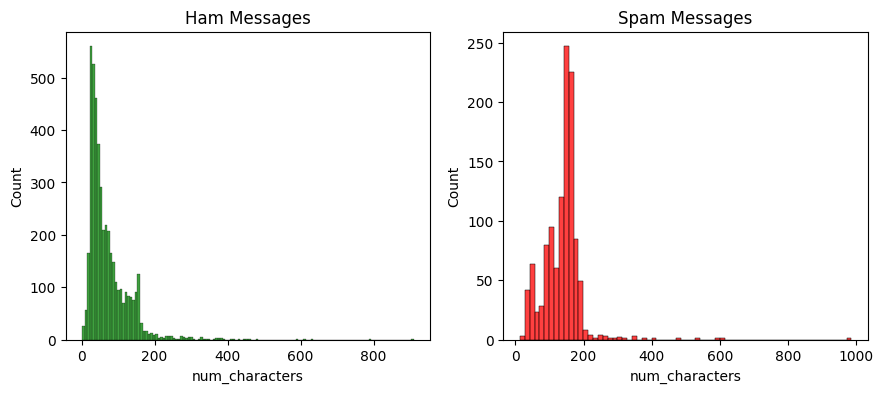

In [74]:
# let's plot the histogram for ham and spam messages
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.histplot(df[df['Type']==0]['num_characters'],color='green')
plt.title('Ham Messages')
plt.subplot(1,3,2)
sns.histplot(df[df['Type']==1]['num_characters'],color='red')
plt.title('Spam Messages')

Text(0.5, 1.0, 'Spam Messages')

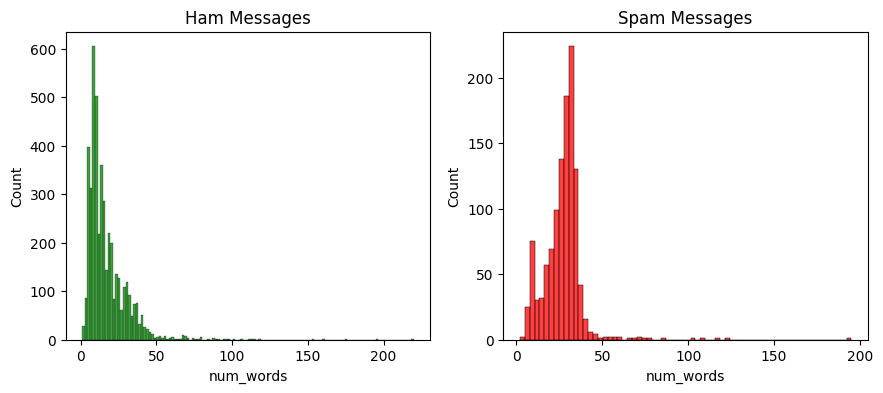

In [75]:
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.histplot(df[df['Type']==0]['num_words'],color='green')
plt.title('Ham Messages')
plt.subplot(1,3,2)
sns.histplot(df[df['Type']==1]['num_words'],color='red')
plt.title('Spam Messages')

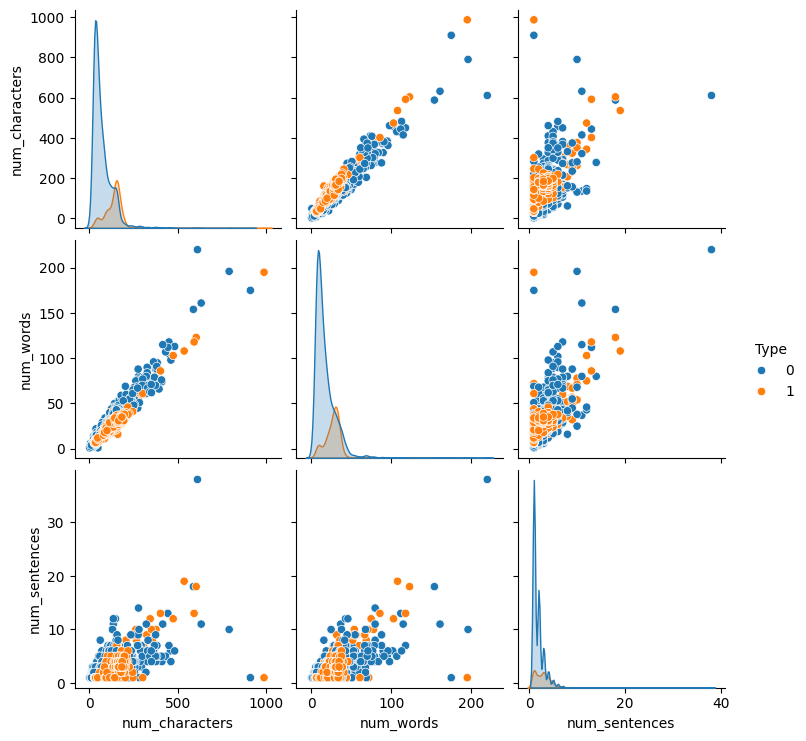

In [76]:
# Let's see the relationship between these features
sns.pairplot(df,hue='Type')

<Axes: >

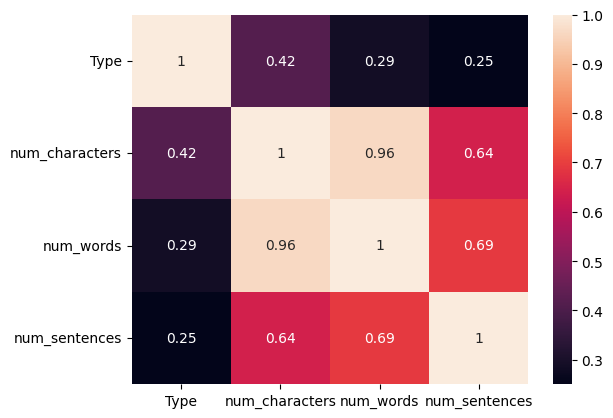

In [77]:
#ignore the text columns and only correlate things like 'num_words', 'num_characters', etc.
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Data/Text preprocessing
#### 1. lowercase
#### 2. Tokenization
#### 3. Removing special character
#### 4. Removing stop words puncution
#### 5. Stemming

In [78]:
# Here we will make a function to do all those thing together
def transform_text(text):
    text = text.lower() # converting the text into lower case
    text = nltk.word_tokenize(text) # tokenization means converting the text into list of words
    y=[]
    for i in text:
        if i.isalnum():
            y.append(i) # removing the special characters

    text = y[:] # copying the list to text
    y.clear() # clearing the list to save memory


    from nltk.corpus import stopwords
    nltk.download('stopwords')
    import string
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i) # removing the stop words and punctuation 
    text = y[:] # copying the list to text
    y.clear() # clearing the list to save memory

    from nltk.stem.porter import PorterStemmer
    ps = PorterStemmer()
    for i in text:
        y.append(ps.stem(i)) # stemming the words

    return "  ".join(y)

In [79]:
df['Transformed_Text'] = df['Text'].apply(transform_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\MSI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_d

In [80]:
df.head()

,Type,Text,num_characters,num_words,num_sentences,Transformed_Text
0,1,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n grea...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup fina...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [81]:
!pip install wordcloud
from wordcloud import WordCloud

(np.float64(-0.5), np.float64(699.5), np.float64(499.5), np.float64(-0.5))

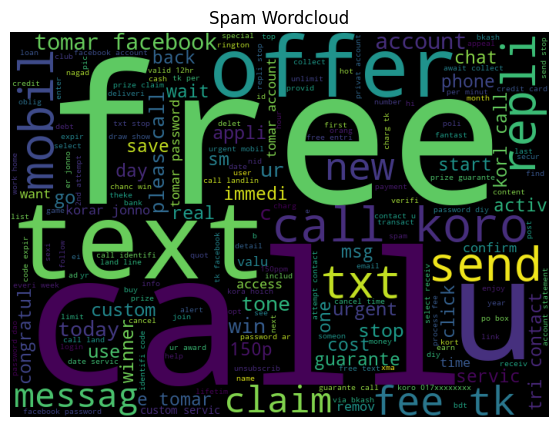

In [82]:
wc = WordCloud(width=700, height=500, min_font_size=10, background_color='black')

wc.generate(df[df['Type']==1]['Transformed_Text'].str.cat(sep=" "))
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Spam Wordcloud")
plt.axis('off')

(np.float64(-0.5), np.float64(699.5), np.float64(499.5), np.float64(-0.5))

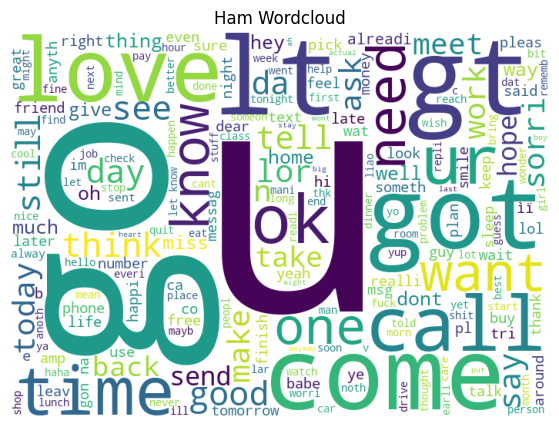

In [83]:
wc = WordCloud(width=700, height=500, min_font_size=10, background_color='white')
wc.generate(df[df['Type']==0]['Transformed_Text'].str.cat(sep=" "))
plt.figure(figsize=(10,5))
plt.imshow(wc)
plt.title("Ham Wordcloud")
plt.axis('off')

In [84]:
# let's top 50 words in ham and spam messages and ham messages
spam_corpus=[]
for message in df[df['Type']==1]['Transformed_Text'].tolist():
    for word in message.split():
        spam_corpus.append(word)

In [85]:
len(spam_corpus)

17896

In [86]:
!pip install collections
from collections import Counter
Counter(spam_corpus).most_common(50)

ERROR: Could not find a version that satisfies the requirement collections (from versions: none)
ERROR: No matching distribution found for collections


[('call', 503),
 ('free', 296),
 ('facebook', 169),
 ('2', 163),
 ('tk', 162),
 ('claim', 145),
 ('tomar', 145),
 ('txt', 141),
 ('account', 135),
 ('mobil', 130),
 ('get', 128),
 ('text', 127),
 ('u', 119),
 ('ur', 119),
 ('repli', 116),
 ('fee', 109),
 ('send', 108),
 ('stop', 108),
 ('prize', 105),
 ('cash', 100),
 ('4', 97),
 ('koro', 95),
 ('offer', 93),
 ('new', 90),
 ('password', 87),
 ('e', 78),
 ('guarante', 73),
 ('today', 73),
 ('servic', 72),
 ('messag', 70),
 ('urgent', 69),
 ('number', 69),
 ('phone', 65),
 ('win', 63),
 ('tone', 63),
 ('custom', 62),
 ('contact', 61),
 ('per', 60),
 ('week', 58),
 ('nokia', 57),
 ('pleas', 56),
 ('award', 55),
 ('appli', 53),
 ('credit', 53),
 ('time', 53),
 ('bkash', 52),
 ('100', 50),
 ('collect', 49),
 ('receiv', 48),
 ('select', 48)]

In [87]:
ham_corpus=[]
for message in df[df['Type']==0]['Transformed_Text'].tolist():
    for word in message.split():
        ham_corpus.append(word)

## Model Building

In [88]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv = CountVectorizer() # bag of words model
tfidf= TfidfVectorizer() # tf-idf model


In [89]:
X= tfidf.fit_transform(df['Transformed_Text']).toarray()
X.shape

(5687, 7108)

In [90]:
y= df['Type'].values

In [91]:
"""
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB
gnb= GaussianNB()
mnb= MultinomialNB()
bnb= BernoulliNB()
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score
"""

'\nfrom sklearn.model_selection import train_test_split\nX_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)\nfrom sklearn.naive_bayes import MultinomialNB, BernoulliNB, GaussianNB\ngnb= GaussianNB()\nmnb= MultinomialNB()\nbnb= BernoulliNB()\nfrom sklearn.metrics import accuracy_score, confusion_matrix, precision_score\n'

In [92]:
"""
# Neive bayes model is usefull in text classification problems
gnb.fit(X_train,y_train)
y_pred1 = gnb.predict(X_test)


print('For GAUSSIAN NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred1)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred1)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred1)}')
"""

"\n# Neive bayes model is usefull in text classification problems\ngnb.fit(X_train,y_train)\ny_pred1 = gnb.predict(X_test)\n\n\nprint('For GAUSSIAN NAIVE BAYES')\nprint('-'*60)\nprint(f'Accuracy score: {accuracy_score(y_test,y_pred1)}')\nprint(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred1)}')\nprint(f'Precision Score:\n {precision_score(y_test,y_pred1)}')\n"

In [93]:
"""
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)

print('For MULTINOMIAL NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred2)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred2)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred2)}')
"""

"\nmnb.fit(X_train,y_train)\ny_pred2 = mnb.predict(X_test)\n\nprint('For MULTINOMIAL NAIVE BAYES')\nprint('-'*60)\nprint(f'Accuracy score: {accuracy_score(y_test,y_pred2)}')\nprint(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred2)}')\nprint(f'Precision Score:\n {precision_score(y_test,y_pred2)}')\n"

In [94]:
"""
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)

print('For BERNOULLI NAIVE BAYES')
print('-'*60)
print(f'Accuracy score: {accuracy_score(y_test,y_pred3)}')
print(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred3)}')
print(f'Precision Score:\n {precision_score(y_test,y_pred3)}')
"""

"\nbnb.fit(X_train,y_train)\ny_pred3 = bnb.predict(X_test)\n\nprint('For BERNOULLI NAIVE BAYES')\nprint('-'*60)\nprint(f'Accuracy score: {accuracy_score(y_test,y_pred3)}')\nprint(f'Confusion Matrix:\n {confusion_matrix(y_test,y_pred3)}')\nprint(f'Precision Score:\n {precision_score(y_test,y_pred3)}')\n"

#### Here we will go with (MULTINOMIAL NAIVE BAYES) because it gives most precission

##### Now we will compare our this model to another ml model to compare the result

In [95]:

"""
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier  
"""
    

'\nfrom sklearn.linear_model import LogisticRegression\nfrom sklearn.svm import SVC\nfrom sklearn.tree import DecisionTreeClassifier\nfrom sklearn.naive_bayes import MultinomialNB\nfrom sklearn.neighbors import KNeighborsClassifier\nfrom sklearn.ensemble import RandomForestClassifier\nfrom sklearn.ensemble import GradientBoostingClassifier\nfrom sklearn.ensemble import AdaBoostClassifier\nfrom xgboost import XGBClassifier  \n'

In [96]:
"""
svc= SVC(kernel='sigmoid', gamma=1.0)
knn= KNeighborsClassifier(n_neighbors=5)
mnb= MultinomialNB()
dtc= DecisionTreeClassifier(max_depth=5)
lrc= LogisticRegression()
rfc= RandomForestClassifier(n_estimators=100, random_state=42)
gbc= GradientBoostingClassifier(n_estimators=100, random_state=42)
abc= AdaBoostClassifier(n_estimators=100, random_state=42)
xgbc= XGBClassifier(n_estimators=100, random_state=42)

"""

"\nsvc= SVC(kernel='sigmoid', gamma=1.0)\nknn= KNeighborsClassifier(n_neighbors=5)\nmnb= MultinomialNB()\ndtc= DecisionTreeClassifier(max_depth=5)\nlrc= LogisticRegression()\nrfc= RandomForestClassifier(n_estimators=100, random_state=42)\ngbc= GradientBoostingClassifier(n_estimators=100, random_state=42)\nabc= AdaBoostClassifier(n_estimators=100, random_state=42)\nxgbc= XGBClassifier(n_estimators=100, random_state=42)\n\n"

In [97]:
"""
clfs={
    'SVC': svc,
    'KNN': knn,
    'NB': mnb,
    'DTC': dtc,
    'LRC': lrc,
    'RFC': rfc,
    'GBC': gbc,
    'ABC': abc,
    'XGBC': xgbc
}
"""

"\nclfs={\n    'SVC': svc,\n    'KNN': knn,\n    'NB': mnb,\n    'DTC': dtc,\n    'LRC': lrc,\n    'RFC': rfc,\n    'GBC': gbc,\n    'ABC': abc,\n    'XGBC': xgbc\n}\n"

In [98]:
"""
def train_classifier(clf, X_train, y_train, X_test, y_test):
    clf.fit(X_train, y_train) # training the model
    y_pred = clf.predict(X_test) # predicting the test set results
    accuracy = accuracy_score(y_test, y_pred) # calculating the accuracy score
    precision = precision_score(y_test, y_pred) # calculating the precision score
    return accuracy, precision

"""

'\ndef train_classifier(clf, X_train, y_train, X_test, y_test):\n    clf.fit(X_train, y_train) # training the model\n    y_pred = clf.predict(X_test) # predicting the test set results\n    accuracy = accuracy_score(y_test, y_pred) # calculating the accuracy score\n    precision = precision_score(y_test, y_pred) # calculating the precision score\n    return accuracy, precision\n\n'

In [99]:
"""
accuracy_scores_list = []
precision_scores_list = []

for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)
    
    print(f"For {name}")
    print(f"Accuracy: {current_accuracy}")
    print(f"Precision: {current_precision}")

    # 2. Append to the new list names
    accuracy_scores_list.append(current_accuracy)
    precision_scores_list.append(current_precision)

"""

'\naccuracy_scores_list = []\nprecision_scores_list = []\n\nfor name, clf in clfs.items():\n    current_accuracy, current_precision = train_classifier(clf, X_train, y_train, X_test, y_test)\n\n    print(f"For {name}")\n    print(f"Accuracy: {current_accuracy}")\n    print(f"Precision: {current_precision}")\n\n    # 2. Append to the new list names\n    accuracy_scores_list.append(current_accuracy)\n    precision_scores_list.append(current_precision)\n\n'

In [100]:
"""
performence_df = pd.DataFrame({"Algorithms": clfs.keys(), "Accuracy": accuracy_scores_list, "Precision": precision_scores_list}).sort_values('Precision',ascending=False)
performence_df

# Here we are seeing NB is giving us the best precision score and accuracy score. So we will use this model for our final model building and improvement.
"""

'\nperformence_df = pd.DataFrame({"Algorithms": clfs.keys(), "Accuracy": accuracy_scores_list, "Precision": precision_scores_list}).sort_values(\'Precision\',ascending=False)\nperformence_df\n\n# Here we are seeing NB is giving us the best precision score and accuracy score. So we will use this model for our final model building and improvement.\n'

In [101]:
# Model improvement
               # applying scalling to the data, we will use minmaxscaler for this, because we have to scale the data for some models like knn, svc, etc. and we will see the improvement in the accuracy and precision score after scaling the data.
# here I don't want scaling because it is giving us good accuracy and precision score. So we will not apply scaling to the data. We will try to improve the model by using different techniques like hyperparameter tuning, feature engineering, etc.


## Note:
#### Here we will use NB algorithm as it is giving best balence in accuracy and precision. 
#### So, I am commenting out the code whcih we have used for model selection

## Exext Model Building

In [102]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.naive_bayes import MultinomialNB
model= MultinomialNB()
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [103]:
model.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [104]:
y_pred= model.predict(X_test)

In [105]:
import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(model, open('model.pkl', 'wb'))